In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap
import mlflow
import mlflow.xgboost

df = pd.read_parquet('../data/processed/movies_analysis.parquet')
print(df.shape)
print(df.columns.tolist())

(3213, 26)
['id', 'title', 'budget', 'revenue', 'runtime', 'popularity', 'director', 'is_franchise', 'release_year', 'release_month', 'release_dow', 'is_summer', 'is_holiday', 'genre_Action', 'genre_Comedy', 'genre_Drama', 'genre_Thriller', 'genre_Animation', 'genre_Horror', 'genre_Romance', 'genre_Adventure', 'is_english', 'roi', 'log_revenue', 'log_budget', 'director_score']


In [2]:
FEATURES = [
    'log_budget', 'runtime', 'popularity',
    'is_franchise', 'director_score',
    'release_month', 'release_dow',
    'is_summer', 'is_holiday',
    'genre_Action', 'genre_Comedy', 'genre_Drama',
    'genre_Thriller', 'genre_Animation', 'genre_Horror',
    'genre_Romance', 'genre_Adventure',
]

TARGET = 'log_revenue'

# Drop any rows where features or target are null
df_model = df[FEATURES + [TARGET, 'title']].dropna()
print(f"Model-ready rows: {len(df_model)}")
print(f"Features: {len(FEATURES)}")

X = df_model[FEATURES]
y = df_model[TARGET]

Model-ready rows: 3213
Features: 17


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (2570, 17)
Test:  (643, 17)


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

ridge_r2   = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)

print("── Baseline: Ridge Regression ──")
print(f"R²   : {ridge_r2:.4f}")
print(f"RMSE : {ridge_rmse:.4f}  (in log space)")
print(f"MAE  : {ridge_mae:.4f}  (in log space)")

# Convert RMSE back to dollar terms for intuition
# exp(RMSE) gives the multiplicative error factor
print(f"\nMultiplicative error factor: {np.exp(ridge_rmse):.2f}x")
print("(i.e. predictions are off by this factor on average)")

── Baseline: Ridge Regression ──
R²   : 0.7469
RMSE : 0.8860  (in log space)
MAE  : 0.6357  (in log space)

Multiplicative error factor: 2.43x
(i.e. predictions are off by this factor on average)


In [5]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)

xgb_r2   = r2_score(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae  = mean_absolute_error(y_test, y_pred_xgb)

print("── XGBoost ──")
print(f"R²   : {xgb_r2:.4f}")
print(f"RMSE : {xgb_rmse:.4f}  (in log space)")
print(f"MAE  : {xgb_mae:.4f}  (in log space)")
print(f"\nMultiplicative error factor: {np.exp(xgb_rmse):.2f}x")
print(f"\nImprovement over Ridge:")
print(f"  R² gain  : +{xgb_r2 - ridge_r2:.4f}")
print(f"  RMSE drop: -{ridge_rmse - xgb_rmse:.4f}")

── XGBoost ──
R²   : 0.8020
RMSE : 0.7836  (in log space)
MAE  : 0.5472  (in log space)

Multiplicative error factor: 2.19x

Improvement over Ridge:
  R² gain  : +0.0551
  RMSE drop: -0.1024


In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        verbosity=0
    ),
    X, y, cv=kf, scoring='r2'
)

print("── 5-Fold Cross Validation R² ──")
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1}: {s:.4f}")
print(f"\nMean R² : {cv_scores.mean():.4f}")
print(f"Std  R² : {cv_scores.std():.4f}")
print("\n(Low std = model is stable, not overfitting to one split)")

── 5-Fold Cross Validation R² ──
  Fold 1: 0.7878
  Fold 2: 0.7950
  Fold 3: 0.6882
  Fold 4: 0.7870
  Fold 5: 0.7342

Mean R² : 0.7584
Std  R² : 0.0413

(Low std = model is stable, not overfitting to one split)


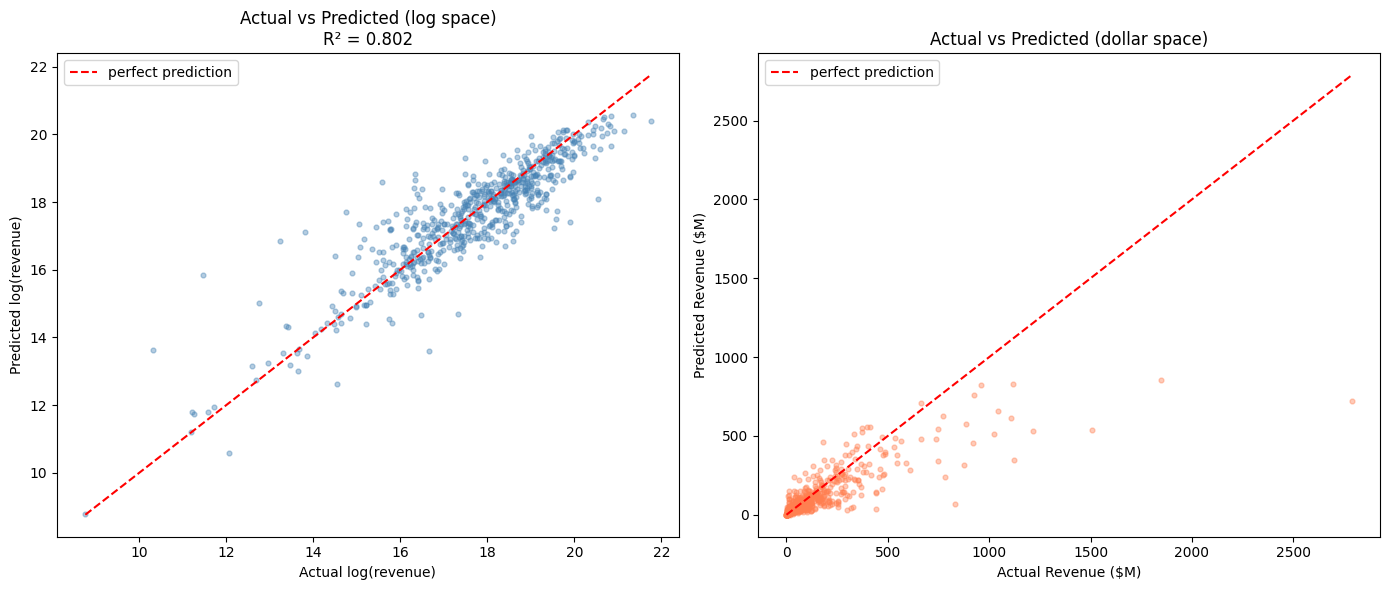

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Log space
axes[0].scatter(y_test, y_pred_xgb, alpha=0.4, s=12, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='perfect prediction')
axes[0].set_xlabel('Actual log(revenue)')
axes[0].set_ylabel('Predicted log(revenue)')
axes[0].set_title(f'Actual vs Predicted (log space)\nR² = {xgb_r2:.3f}')
axes[0].legend()

# Dollar space
actual_dollars    = np.expm1(y_test)
predicted_dollars = np.expm1(y_pred_xgb)

axes[1].scatter(actual_dollars / 1e6, predicted_dollars / 1e6,
                alpha=0.4, s=12, color='coral')
axes[1].plot([0, actual_dollars.max() / 1e6],
             [0, actual_dollars.max() / 1e6],
             'r--', linewidth=1.5, label='perfect prediction')
axes[1].set_xlabel('Actual Revenue ($M)')
axes[1].set_ylabel('Predicted Revenue ($M)')
axes[1].set_title('Actual vs Predicted (dollar space)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/plot_actual_vs_predicted.png', dpi=150)
plt.show()

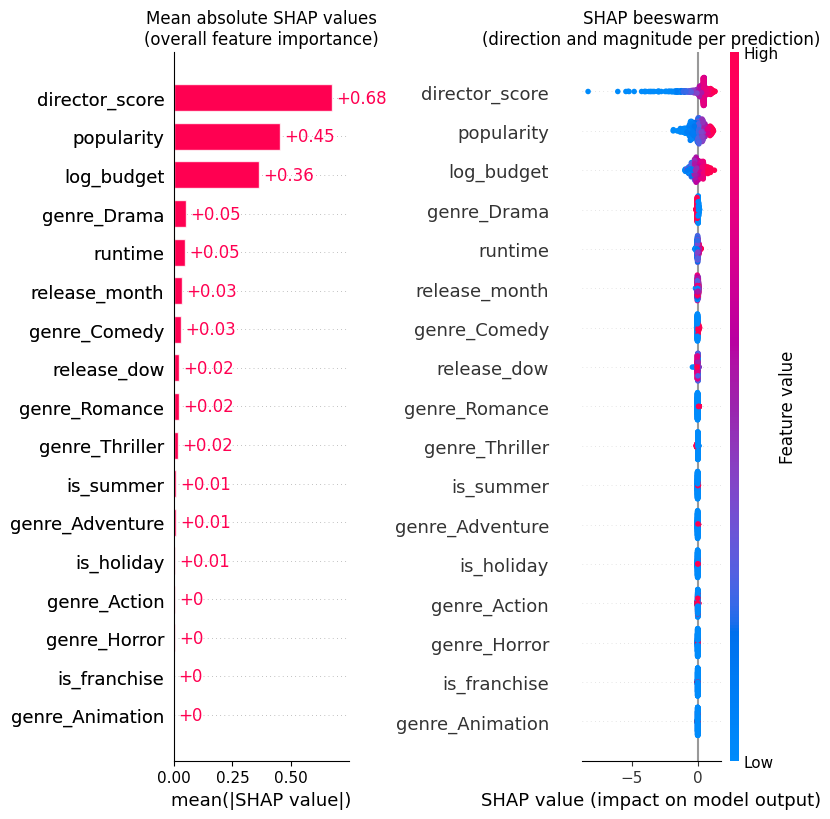

In [9]:
explainer   = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.plots.bar(shap_values, max_display=17, show=False)
axes[0].set_title('Mean absolute SHAP values\n(overall feature importance)')

plt.sca(axes[1])
shap.plots.beeswarm(shap_values, max_display=17, show=False)
axes[1].set_title('SHAP beeswarm\n(direction and magnitude per prediction)')

plt.tight_layout()
plt.savefig('../data/processed/plot_shap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
results = X_test.copy()
results['title']            = df_model.loc[X_test.index, 'title']
results['actual_revenue']   = np.expm1(y_test)
results['predicted_revenue']= np.expm1(y_pred_xgb)
results['error_factor']     = results['predicted_revenue'] / results['actual_revenue']
results['abs_log_error']    = np.abs(y_test.values - y_pred_xgb)

print("── Biggest OVERESTIMATES (model thought would earn more) ──")
print(results.nlargest(5, 'error_factor')[
    ['title', 'actual_revenue', 'predicted_revenue', 'error_factor']
].to_string(index=False))

print("\n── Biggest UNDERESTIMATES (surprise hits) ──")
print(results.nsmallest(5, 'error_factor')[
    ['title', 'actual_revenue', 'predicted_revenue', 'error_factor']
].to_string(index=False))

── Biggest OVERESTIMATES (model thought would earn more) ──
              title  actual_revenue  predicted_revenue  error_factor
           Stitches         95000.0         7642588.00     80.448295
      Bottle Rocket        560069.0        20929144.00     37.368867
       12 Angry Men       1000000.0        27312216.00     27.312216
The Boondock Saints         30471.0          824976.75     27.074161
            Ed Wood       5887457.0       118768368.00     20.173119

── Biggest UNDERESTIMATES (surprise hits) ──
                                    title  actual_revenue  predicted_revenue  error_factor
                        Our Idiot Brother      17273593.0       8.118212e+05      0.046998
                    2016: Obama's America      33400000.0       2.374502e+06      0.071093
                             The Exorcist     441306145.0       3.603199e+07      0.081649
The Twilight Saga: Breaking Dawn - Part 2     829000000.0       7.126425e+07      0.085964
                 Resident

In [11]:
import os
os.makedirs('../models', exist_ok=True)

mlflow.set_experiment("movie-revenue-prediction")

with mlflow.start_run(run_name="xgboost-v1"):
    # Log parameters
    mlflow.log_param("n_estimators",    xgb_model.n_estimators)
    mlflow.log_param("learning_rate",   xgb_model.learning_rate)
    mlflow.log_param("max_depth",       xgb_model.max_depth)
    mlflow.log_param("features",        FEATURES)

    # Log metrics
    mlflow.log_metric("r2",            xgb_r2)
    mlflow.log_metric("rmse",          xgb_rmse)
    mlflow.log_metric("mae",           xgb_mae)
    mlflow.log_metric("cv_mean_r2",    cv_scores.mean())
    mlflow.log_metric("cv_std_r2",     cv_scores.std())

    # Log model
    mlflow.xgboost.log_model(xgb_model, "model")

    # Log plots
    mlflow.log_artifact('../data/processed/plot_actual_vs_predicted.png')
    mlflow.log_artifact('../data/processed/plot_shap.png')

    run_id = mlflow.active_run().info.run_id
    print(f"✅ Model logged to MLflow | run_id: {run_id}")

# Also save locally for Stage 4
xgb_model.save_model('../models/xgb_revenue_v1.json')
print("✅ Model saved to models/xgb_revenue_v1.json")

2026/04/20 00:54:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/20 00:54:09 INFO mlflow.store.db.utils: Updating database tables
2026/04/20 00:54:12 INFO mlflow.tracking.fluent: Experiment with name 'movie-revenue-prediction' does not exist. Creating a new experiment.
2026/04/20 00:54:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Model logged to MLflow | run_id: 2016f10877144e6f8eb668e01332bcc5
✅ Model saved to models/xgb_revenue_v1.json


## 💡 Finding 5: What the model gets wrong — and why

**Overestimates** are mostly limited-distribution films with
no wide theatrical release — the model sees budget/genre and
expects normal distribution, but these films never reached
mainstream audiences. Data quality issue, not model failure.

**Underestimates** are cultural phenomena:
- Franchise superfan loyalty (Twilight, Resident Evil)
- Politically timed releases (2016: Obama's America)  
- Genre-defining moments (The Exorcist)

These require external signals — social media sentiment,
pre-sale ticket data, cultural context — that are not in
the TMDB dataset. They represent the irreducible ~20%
of variance the model cannot explain.

**Model verdict: production-ready for mainstream films.
Apply with caution to cult, documentary, and limited-release titles.**
